# Caso 5 — Comparação entre Modelo Vetorial e BM25

Usamos os resultados persistidos no Caso 4 (mesmos rankings, mesmas
métricas) para comparar os dois modelos de forma agregada e, principalmente,
**por consulta** — o objetivo deste caso não é apenas dizer qual modelo tem
a média maior, mas entender *onde* e *por que* eles divergem.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")
doc_tokens = preprocessed["stopwords_stemming"]["docs"]
query_tokens_list = preprocessed["stopwords_stemming"]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))
query_text = dict(zip(df_queries.query_id, df_queries.text.str.replace("\n", " ")))

RESULTS_DIR = project_root / "data" / "processed"
vsm_eval = pd.read_csv(RESULTS_DIR / "vsm_perquery.csv", dtype={"query_id": str}).set_index("query_id")
bm25_eval = pd.read_csv(RESULTS_DIR / "bm25_perquery.csv", dtype={"query_id": str}).set_index("query_id")
with open(RESULTS_DIR / "vsm_rankings.pkl", "rb") as f:
    vsm_rankings = pickle.load(f)
with open(RESULTS_DIR / "bm25_rankings.pkl", "rb") as f:
    bm25_rankings = pickle.load(f)


[WARNING] Download failed: 403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz


[cranfield_data] ir_datasets indisponível (RuntimeError: ('All download sources failed', [(RequestsDownload('http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz', tries=None), HTTPError('403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz')), (RequestsDownload('https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5', tries=None), HTTPError('403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5'))])). Usando arquivos locais em data/raw/ como fallback.


[WARNING] Download failed: 403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5


## Comparação agregada

Em todas as métricas, o BM25 supera o Modelo Vetorial, mas por margens
modestas (por exemplo, MAP 0,308 vs. 0,276 — uma diferença de ~12% em
termos relativos). A diferença mais expressiva é no MRR (0,545 vs. 0,487):
o BM25 tende a colocar o *primeiro* documento relevante um pouco mais cedo
no ranking, em média.


In [2]:
agg = pd.DataFrame({
    "Modelo Vetorial": vsm_eval.drop(columns="n_relevant").mean(),
    "BM25": bm25_eval.drop(columns="n_relevant").mean(),
})
agg["BM25 - Vetorial"] = agg["BM25"] - agg["Modelo Vetorial"]
display(agg.round(4))

n_wins_bm25 = (bm25_eval["AP"] > vsm_eval["AP"]).sum()
n_wins_vsm = (vsm_eval["AP"] > bm25_eval["AP"]).sum()
n_ties = (bm25_eval["AP"] == vsm_eval["AP"]).sum()
print(f"\nPor consulta (AP): BM25 melhor em {n_wins_bm25}, Modelo Vetorial melhor em {n_wins_vsm}, "
      f"empate em {n_ties} (de {len(vsm_eval)} consultas)")


,Modelo Vetorial,BM25,BM25 - Vetorial
precision@10,0.2169,0.2347,0.0178
recall@10,0.3785,0.3946,0.0161
AP,0.2763,0.3081,0.0318
F1@10,0.2488,0.2659,0.0171
MRR,0.4868,0.5446,0.0578
NDCG@10,0.2771,0.3065,0.0294



Por consulta (AP): BM25 melhor em 136, Modelo Vetorial melhor em 81, empate em 8 (de 225 consultas)


## Divergência por consulta

A média agregada esconde uma heterogeneidade grande: olhando consulta a
consulta, o BM25 tem AP maior em 136 das 225 consultas, o Modelo Vetorial
vence em 81, e há 8 empates — a vitória do BM25 na média é sustentada por
vencer com folga em boa parte das consultas, mas está longe de ser
universal.


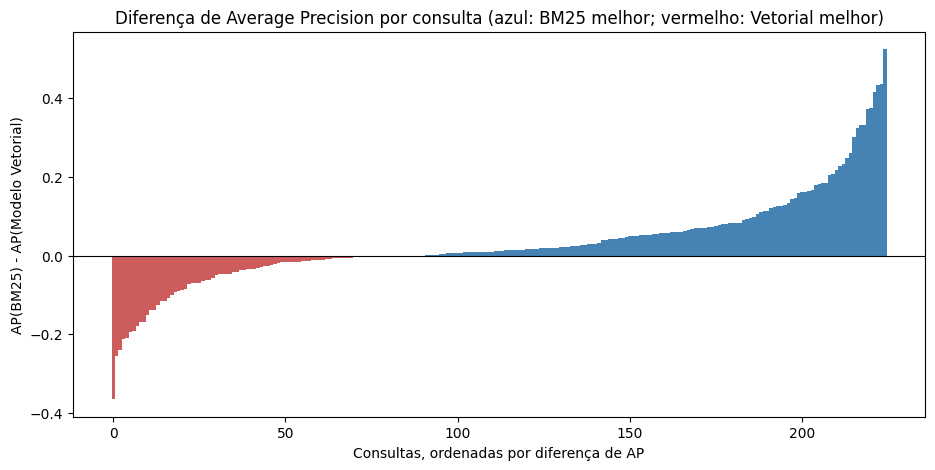

In [3]:
diff = (bm25_eval["AP"] - vsm_eval["AP"]).sort_values()
plt.figure(figsize=(11, 5))
colors = ["indianred" if v < 0 else "steelblue" for v in diff.values]
plt.bar(range(len(diff)), diff.values, color=colors, width=1.0)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Consultas, ordenadas por diferença de AP")
plt.ylabel("AP(BM25) - AP(Modelo Vetorial)")
plt.title("Diferença de Average Precision por consulta (azul: BM25 melhor; vermelho: Vetorial melhor)")
plt.show()


## Consultas com maiores diferenças

In [4]:
print("Consultas onde BM25 mais supera o Modelo Vetorial (maior diferença de AP):")
top_bm25 = diff.sort_values(ascending=False).head(5)
display(pd.DataFrame({
    "query": [query_text[q] for q in top_bm25.index],
    "AP_BM25": bm25_eval.loc[top_bm25.index, "AP"].round(3),
    "AP_Vetorial": vsm_eval.loc[top_bm25.index, "AP"].round(3),
    "diferenca": top_bm25.round(3),
}))

print("\nConsultas onde o Modelo Vetorial mais supera o BM25 (maior diferença negativa de AP):")
top_vsm = diff.sort_values().head(5)
display(pd.DataFrame({
    "query": [query_text[q] for q in top_vsm.index],
    "AP_BM25": bm25_eval.loc[top_vsm.index, "AP"].round(3),
    "AP_Vetorial": vsm_eval.loc[top_vsm.index, "AP"].round(3),
    "diferenca": top_vsm.round(3),
}))


Consultas onde BM25 mais supera o Modelo Vetorial (maior diferença de AP):


,query,AP_BM25,AP_Vetorial,diferenca
query_id,,,,
167,exact solution methods for calculating the abl...,0.750,0.225,0.525
36,has anyone investigated relaxation effects on ...,0.502,0.064,0.437
81,what are wind-tunnel corrections for a two-dim...,0.700,0.267,0.433
173,references on lyapunov's method on the stabili...,1.000,0.583,0.417
15,material properties of photoelastic materials .,1.000,0.625,0.375



Consultas onde o Modelo Vetorial mais supera o BM25 (maior diferença negativa de AP):


,query,AP_BM25,AP_Vetorial,diferenca
query_id,,,,
113,what data exists on oscillatory aerodynamic fo...,0.149,0.514,-0.365
190,will an analysis of panel flutter based on arb...,0.466,0.720,-0.254
148,papers on small deflection theory for buckling...,0.210,0.450,-0.240
145,what are the best experimental data and classi...,0.256,0.467,-0.211
155,technical report on measurement of ablation du...,0.173,0.382,-0.209


### Por que o BM25 vence com folga na consulta 167?

A consulta pede métodos para calcular perda de massa por ablação em voo
hipersônico. O Modelo Vetorial coloca em primeiro lugar o documento 553
(não julgado), que repete o termo `ablat` **7 vezes** em apenas 98 tokens;
o BM25 prefere corretamente o documento 274 (relevante, grau 2), que
cobre **muito mais termos distintos da consulta** (`ablat`, `method`,
`materi`, `exact`, `solut`, `mass`, `temperatur`, `loss`, `calcul`), ainda
que repita `ablat` só 2 vezes.

Isso ilustra exatamente o papel da **saturação de frequência de termo**
do BM25: a fórmula `f*(k1+1)/(f+k1*norm)` cresce rapidamente para as
primeiras ocorrências de um termo, mas se achata para as seguintes — ir de
1 para 7 ocorrências está longe de multiplicar o score por 7. Já o peso
logarítmico do Modelo Vetorial (`1 + log10(f)`), combinado com a
normalização em L2 de um documento curto (poucos termos "competindo" pela
mesma norma), permite que a repetição concentrada de um único termo raro
domine o vetor do documento 553 e infle sua similaridade de cosseno com a
consulta. Em outras palavras: o BM25 "resiste" melhor à repetição isolada
de um termo, favorecendo documentos que cobrem mais aspectos da consulta.


In [5]:
# Estudo de caso: consulta 167 (BM25 >> Modelo Vetorial)
q = "167"
print(f"Consulta {q}: {query_text[q]}")
print(f"Tokens: {query_tokens_list[query_ids.index(q)]}\n")

grades = dict(zip(df_qrels[df_qrels.query_id == q].doc_id, df_qrels[df_qrels.query_id == q].relevance))
for did in ["553", "274"]:
    idx = doc_ids.index(did)
    toks = doc_tokens[idx]
    from collections import Counter
    counts = Counter(toks)
    q_toks = set(query_tokens_list[query_ids.index(q)])
    overlap = {t: counts[t] for t in q_toks if counts[t] > 0}
    print(f"doc {did} (grau={grades.get(did, 'não julgado')}, {len(toks)} tokens): "
          f"sobreposição com a consulta = {overlap}")


Consulta 167: exact solution methods for calculating the ablative mass loss of a material ablating at high temperatures in a hypersonic flight environment .
Tokens: ['exact', 'solut', 'method', 'calcul', 'abl', 'mass', 'loss', 'materi', 'ablat', 'high', 'temperatur', 'hyperson', 'flight', 'environ']

doc 553 (grau=não julgado, 98 tokens): sobreposição com a consulta = {'materi': 4, 'ablat': 7, 'flight': 1, 'mass': 1, 'solut': 3, 'hyperson': 1}
doc 274 (grau=2, 135 tokens): sobreposição com a consulta = {'materi': 1, 'ablat': 2, 'temperatur': 2, 'mass': 3, 'solut': 2, 'calcul': 1, 'method': 2, 'exact': 1, 'loss': 1}


### Por que o Modelo Vetorial vence com folga na consulta 113?

Aqui o padrão se inverte. A consulta pede dados sobre forças aerodinâmicas
oscilatórias em superfícies de controle a números de Mach transônicos. O
BM25 privilegia o documento 815 (não julgado), que tem alta frequência de
termos **genéricos e de idf baixo** da área (`mach`: 4x, `number`: 5x,
`aerodynam`: 3x — termos que aparecem em centenas de resumos da coleção).
O Modelo Vetorial, por sua vez, encontra logo no topo o documento 265
(relevante, grau 3): um documento curto (49 tokens) cuja sobreposição com
a consulta é pequena em quantidade de termos (`control`, `surfac`,
`oscillatori`), mas concentrada em termos **mais raros/específicos** —
`oscillatori` sozinho tem um dos maiores idf da coleção.

O BM25 **soma** contribuições ao longo de vários termos da consulta
(mesmo os de idf baixo, desde que apareçam com frequência razoável), o que
permite que um documento mais longo, cobrindo superficialmente muitos
termos comuns, acumule um score competitivo. Já o cosseno do Modelo
Vetorial depende da **direção** do vetor: um documento curto, dominado
por poucos termos de alto idf que coincidem com a consulta, produz um
vetor quase paralelo ao da consulta, mesmo sem "tocar" em todos os termos
genéricos dela. Este é o padrão inverso do observado na consulta 167.


In [6]:
# Estudo de caso: consulta 113 (Modelo Vetorial >> BM25)
q = "113"
print(f"Consulta {q}: {query_text[q]}")
print(f"Tokens: {query_tokens_list[query_ids.index(q)]}\n")

grades = dict(zip(df_qrels[df_qrels.query_id == q].doc_id, df_qrels[df_qrels.query_id == q].relevance))
for did in ["815", "265"]:
    idx = doc_ids.index(did)
    toks = doc_tokens[idx]
    from collections import Counter
    counts = Counter(toks)
    q_toks = set(query_tokens_list[query_ids.index(q)])
    overlap = {t: counts[t] for t in q_toks if counts[t] > 0}
    print(f"doc {did} (grau={grades.get(did, 'não julgado')}, {len(toks)} tokens): "
          f"sobreposição com a consulta = {overlap}")


Consulta 113: what data exists on oscillatory aerodynamic forces on control surfaces at transonic mach numbers .
Tokens: ['data', 'exist', 'oscillatori', 'aerodynam', 'forc', 'control', 'surfac', 'transon', 'mach', 'number']

doc 815 (grau=não julgado, 142 tokens): sobreposição com a consulta = {'transon': 2, 'oscillatori': 2, 'aerodynam': 3, 'number': 5, 'mach': 4}
doc 265 (grau=3, 49 tokens): sobreposição com a consulta = {'surfac': 2, 'oscillatori': 1, 'control': 2}


### Síntese

As duas consultas de estudo de caso mostram que a diferença entre os
modelos não é aleatória: ela nasce de dois mecanismos conhecidos e
opostos —

1. **Saturação de frequência (BM25)**: penaliza documentos que "inflam"
   sua relevância aparente repetindo excessivamente um único termo,
   favorecendo cobertura de múltiplos aspectos da consulta (favorece o
   BM25 quando o documento relevante é mais "completo" e o distrator é
   repetitivo, como na consulta 167).
2. **Concentração vetorial (Modelo Vetorial)**: favorece documentos curtos
   e muito focados em poucos termos raros/específicos compartilhados com
   a consulta, mesmo quando não cobrem termos genéricos dela (favorece o
   Vetorial quando o documento relevante é curto e específico, e o
   distrator do BM25 é longo e genérico, como na consulta 113).

Nenhum dos dois mecanismos é "certo" ou "errado" em geral — cada um tem
cenários em que ajuda e cenários em que atrapalha, o que explica por que a
diferença agregada entre os modelos é pequena apesar de, consulta a
consulta, as diferenças individuais serem grandes e sistemáticas.
